In [84]:
import pandas as pd
import psycopg
from datetime import datetime, time
import mplfinance as mpf

In [85]:
TARGET_DATE = "2025-08-12"
CUTOFF_TIME = "08:22:00"

In [86]:
conn = psycopg.connect(
    "dbname=dailyedge_development"
)

In [87]:
target_date = pd.Timestamp(TARGET_DATE)

start_time = target_date - pd.Timedelta(days=565)
cutoff = pd.Timestamp(f"{TARGET_DATE} {CUTOFF_TIME}")

query = """
    SELECT timestamp, open, high, low, close, volume
    FROM CANDLES
    WHERE timestamp >= %s
    AND timestamp <= %s
    ORDER BY timestamp
"""

df = pd.read_sql(query, conn, params=(start_time, cutoff))

df.head(), df.tail(), len(df)

/tmp/ipykernel_10023/2385005615.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn, params=(start_time, cutoff))


(            timestamp          open          high           low         close  \
 0 2024-01-25 00:00:00  19437.467702  19437.743399  19434.986429  19437.192005   
 1 2024-01-25 00:01:00  19436.916308  19438.019096  19435.813520  19438.019096   
 2 2024-01-25 00:02:00  19437.743399  19437.743399  19430.850974  19431.953762   
 3 2024-01-25 00:03:00  19431.953762  19432.780853  19428.369700  19432.780853   
 4 2024-01-25 00:04:00  19432.505156  19433.883641  19430.575277  19430.575277   
 
    volume  
 0      66  
 1      34  
 2     142  
 3     111  
 4      69  ,
                  timestamp          open          high           low  \
 546716 2025-08-12 08:18:00  24663.144050  24666.001016  24659.507913   
 546717 2025-08-12 08:19:00  24661.066257  24662.884326  24656.650947   
 546718 2025-08-12 08:20:00  24661.845430  24662.105154  24650.677292   
 546719 2025-08-12 08:21:00  24650.937016  24658.988464  24647.041154   
 546720 2025-08-12 08:22:00  24649.118947  24651.716188  24645

In [88]:
df = df.set_index("timestamp")
df.tail()

,open,high,low,close,volume
timestamp,,,,,
2025-08-12 08:18:00,24663.144050,24666.001016,24659.507913,24661.066257,314
2025-08-12 08:19:00,24661.066257,24662.884326,24656.650947,24662.364878,262
2025-08-12 08:20:00,24661.845430,24662.105154,24650.677292,24651.456464,226
2025-08-12 08:21:00,24650.937016,24658.988464,24647.041154,24649.378671,453
2025-08-12 08:22:00,24649.118947,24651.716188,24645.482809,24648.339775,351


In [89]:
df_5m = df.resample("5min").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
}).dropna()

df_5m.tail(10)

,open,high,low,close,volume
timestamp,,,,,
2025-08-12 07:35:00,24682.103912,24731.711222,24680.026119,24718.465291,6474
2025-08-12 07:40:00,24717.945843,24748.853015,24704.180464,24711.193015,5133
2025-08-12 07:45:00,24711.452739,24729.373705,24702.622119,24723.919498,3098
2025-08-12 07:50:00,24724.179222,24724.958394,24709.894395,24720.283360,1841
2025-08-12 07:55:00,24720.802808,24725.997291,24691.973429,24697.947084,3377
2025-08-12 08:00:00,24697.167912,24709.115222,24664.962119,24668.857981,4892
2025-08-12 08:05:00,24669.117705,24673.013567,24649.378671,24659.767637,3451
2025-08-12 08:10:00,24660.027361,24670.935774,24654.053706,24662.105154,2410
2025-08-12 08:15:00,24661.066257,24666.520464,24650.677292,24662.364878,1858


In [90]:
df_30m = df.resample("30min").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
}).dropna()

df_30m.tail(10)

,open,high,low,close,volume
timestamp,,,,,
2025-08-12 03:30:00,24571.201707,24576.915638,24554.059914,24560.812742,1308
2025-08-12 04:00:00,24560.812742,24569.643362,24555.358535,24564.968328,1091
2025-08-12 04:30:00,24565.228052,24572.500328,24553.280742,24555.358535,1492
2025-08-12 05:00:00,24555.358535,24564.968328,24544.969569,24553.800190,1957
2025-08-12 05:30:00,24553.800190,24561.591914,24548.865431,24554.579362,1325
2025-08-12 06:00:00,24554.839086,24555.618259,24526.788880,24542.891776,2418
2025-08-12 06:30:00,24542.891776,24561.851638,24528.866673,24560.033569,2877
2025-08-12 07:00:00,24560.553017,24600.031086,24558.215500,24589.382396,4787
2025-08-12 07:30:00,24583.149017,24748.853015,24582.889293,24697.947084,29774


In [91]:
df_4h = df.resample("4h", offset="1h").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
}).dropna()

df_4h.tail(10)

,open,high,low,close,volume
timestamp,,,,,
2025-08-10 17:00:00,24688.337291,24695.349843,24622.886810,24682.363636,17956
2025-08-10 21:00:00,24682.103912,24697.687360,24654.573154,24662.105154,11956
2025-08-11 01:00:00,24662.884326,24688.856740,24588.343500,24646.002258,22346
2025-08-11 05:00:00,24645.482809,24680.285843,24601.849155,24668.338533,76276
2025-08-11 09:00:00,24668.338533,24730.412601,24609.900603,24619.510396,189493
2025-08-11 13:00:00,24619.770120,24623.146534,24504.972053,24548.605707,121345
2025-08-11 17:00:00,24554.319638,24587.304603,24533.022259,24578.993431,13785
2025-08-11 21:00:00,24579.772603,24597.693569,24513.802673,24548.605707,11850
2025-08-12 01:00:00,24549.125156,24596.394948,24546.527914,24555.358535,13247


In [92]:
df_1d = df.resample("24h", offset="17h").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
}).dropna()

df_1d.tail(10)

,open,high,low,close,volume
timestamp,,,,,
2025-07-29 17:00:00,24364.201572,24610.420051,24264.986953,24582.110121,527608
2025-07-30 17:00:00,24627.042396,24772.487911,24196.419781,24236.936746,728989
2025-07-31 17:00:00,24215.119919,24255.636884,23660.868617,23759.563788,792191
2025-08-03 17:00:00,23738.785857,24260.831367,23709.437030,24259.013298,463895
2025-08-04 17:00:00,24262.389711,24314.594262,23982.407095,23990.198819,536306
2025-08-05 17:00:00,23989.939095,24357.189020,23941.890130,24323.944331,516364
2025-08-06 17:00:00,24329.398538,24591.719914,24236.417298,24436.664605,554806
2025-08-07 17:00:00,24433.028468,24692.233153,24417.185295,24689.895636,447596
2025-08-10 17:00:00,24688.337291,24730.412601,24504.972053,24548.605707,439372


In [93]:
current_price = df.iloc[-1]["close"]
current_price

np.float64(24648.339775)

In [94]:
overnight_start = pd.Timestamp(TARGET_DATE) - pd.Timedelta(days=1) + pd.Timedelta(hours=17)

overnight = df.loc[overnight_start:cutoff]

overnight_high = overnight["high"].max()
overnight_low = overnight["low"].min()
overnight_range = overnight_high - overnight_low

overnight_high, overnight_low, overnight_range

(np.float64(24748.853015),
 np.float64(24513.802673),
 np.float64(235.05034200000227))

In [95]:
previous_date = pd.Timestamp(TARGET_DATE) - pd.Timedelta(days=1)

previous_rth = df.loc[
    f"{previous_date.date()} 08:30:00":
    f"{previous_date.date()} 15:00:00"
]

previous_day_range = previous_rth["high"].max() - previous_rth["low"].min()

previous_day_range

np.float64(225.44054799999867)

In [96]:
previous_close_time = pd.Timestamp(
    f"{previous_date.date()} 15:15:00"
)

previous_close = df.loc[previous_close_time, "close"]

org = current_price - previous_close

previous_close, org


(np.float64(24547.826535), np.float64(100.51324000000022))

In [97]:
completed_daily = df_1d.iloc[:-1].copy()

completed_daily["prev_close"] = completed_daily["close"].shift(1)

completed_daily["true_range"] = pd.concat([
    completed_daily["high"] - completed_daily["low"],
    (completed_daily["high"] - completed_daily["prev_close"]).abs(),
    (completed_daily["low"] - completed_daily["prev_close"]).abs()
], axis=1).max(axis=1)

atr_14 = completed_daily["true_range"].tail(14).mean()

atr_14

np.float64(330.66592614285685)

In [98]:
context = {
    "date": TARGET_DATE,
    "cutoff_time_ct": CUTOFF_TIME,
    "current_price": round(current_price, 2),
    "atr_14": round(atr_14, 2),
    "overnight_high": round(overnight_high, 2),
    "overnight_low": round(overnight_low, 2),
    "overnight_range": round(overnight_range, 2),
    "previous_day_range": round(previous_day_range, 2),
    "org": round(org, 2),
}

context

{'date': '2025-08-12',
 'cutoff_time_ct': '08:22:00',
 'current_price': np.float64(24648.34),
 'atr_14': np.float64(330.67),
 'overnight_high': np.float64(24748.85),
 'overnight_low': np.float64(24513.8),
 'overnight_range': np.float64(235.05),
 'previous_day_range': np.float64(225.44),
 'org': np.float64(100.51)}

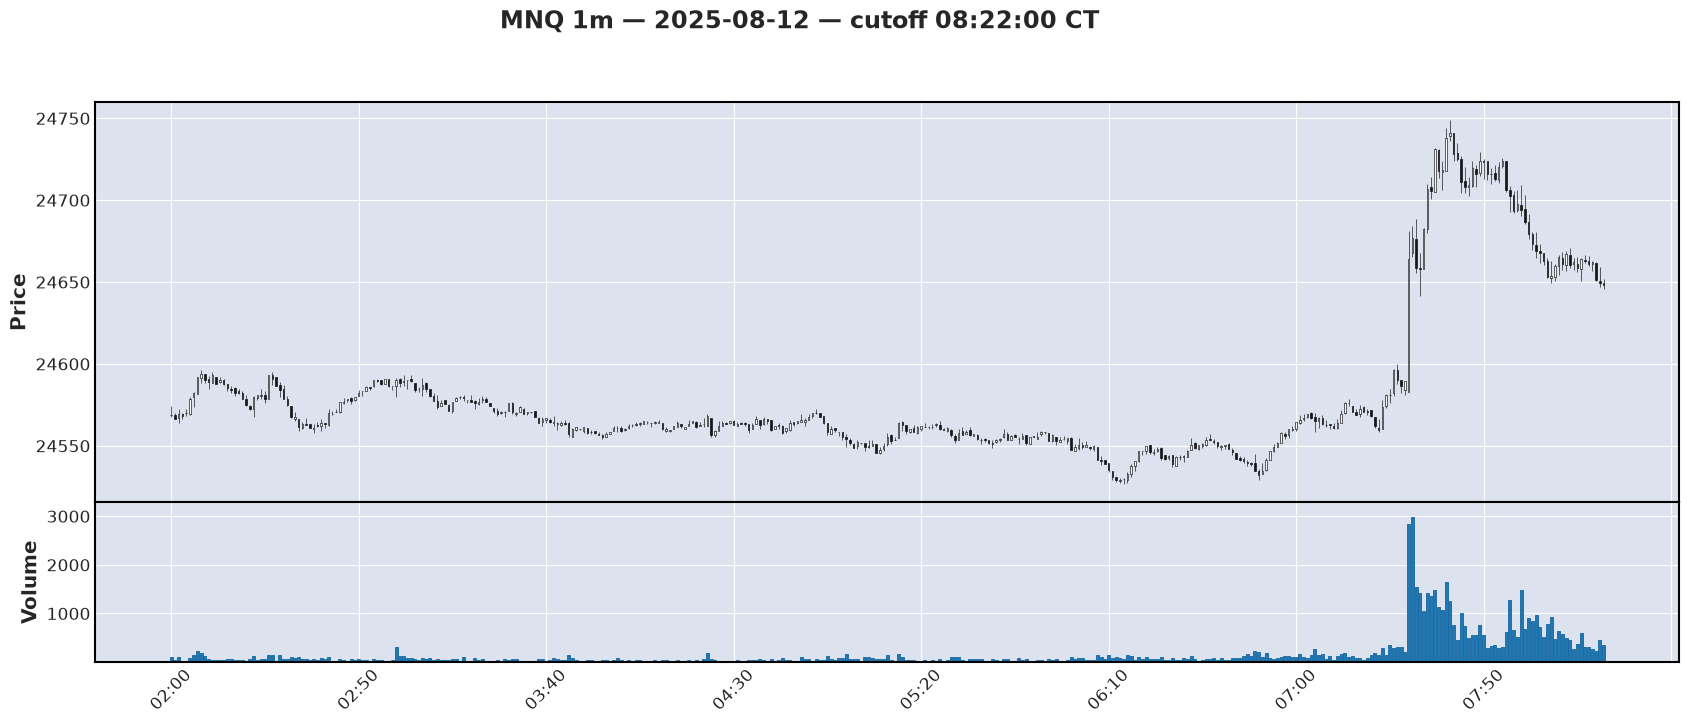

In [107]:
chart_1m = df.loc[
    f"{TARGET_DATE} 02:00:00":
    cutoff
]

mpf.plot(
    chart_1m,
    type="candle",
    volume=True,
    figsize=(22, 8),
    title=f"MNQ 1m — {TARGET_DATE} — cutoff {CUTOFF_TIME} CT",
    warn_too_much_data=1000,
)

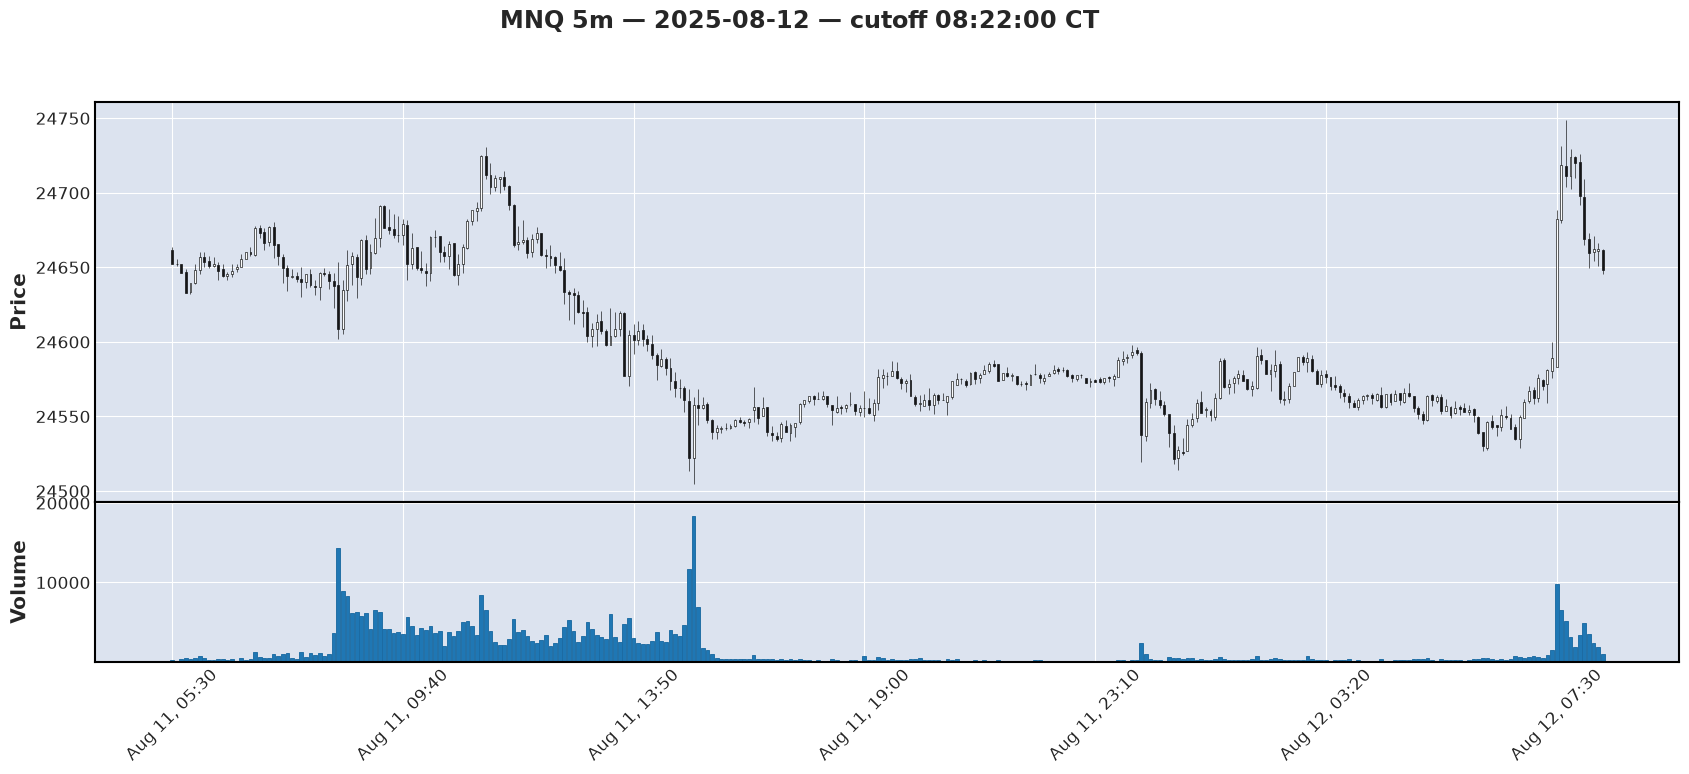

In [116]:
chart_5m = df_5m.loc[
    f"{previous_date.date()} 05:30:00":
    f"{TARGET_DATE} {CUTOFF_TIME}"
]

mpf.plot(
    chart_5m,
    type="candle",
    volume=True,
    figsize=(22, 8),
    title=f"MNQ 5m — {TARGET_DATE} — cutoff {CUTOFF_TIME} CT"
)

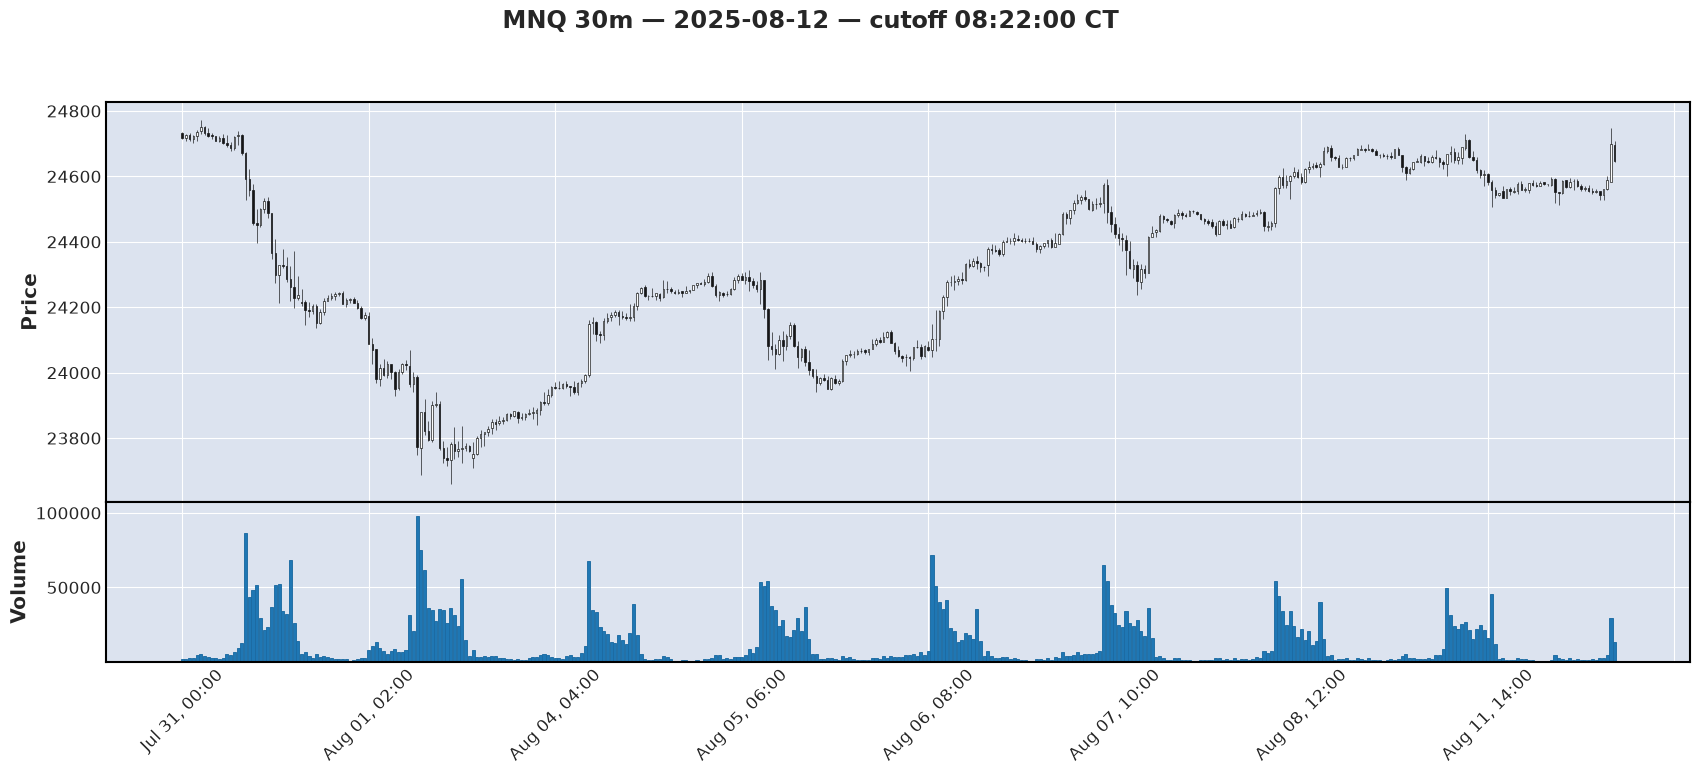

In [110]:
chart_30m = df_30m.loc[
    target_date - pd.Timedelta(days=12):
    cutoff
]

mpf.plot(
    chart_30m,
    type="candle",
    volume=True,
    figsize=(22, 8),
    title=f"MNQ 30m — {TARGET_DATE} — cutoff {CUTOFF_TIME} CT"
)

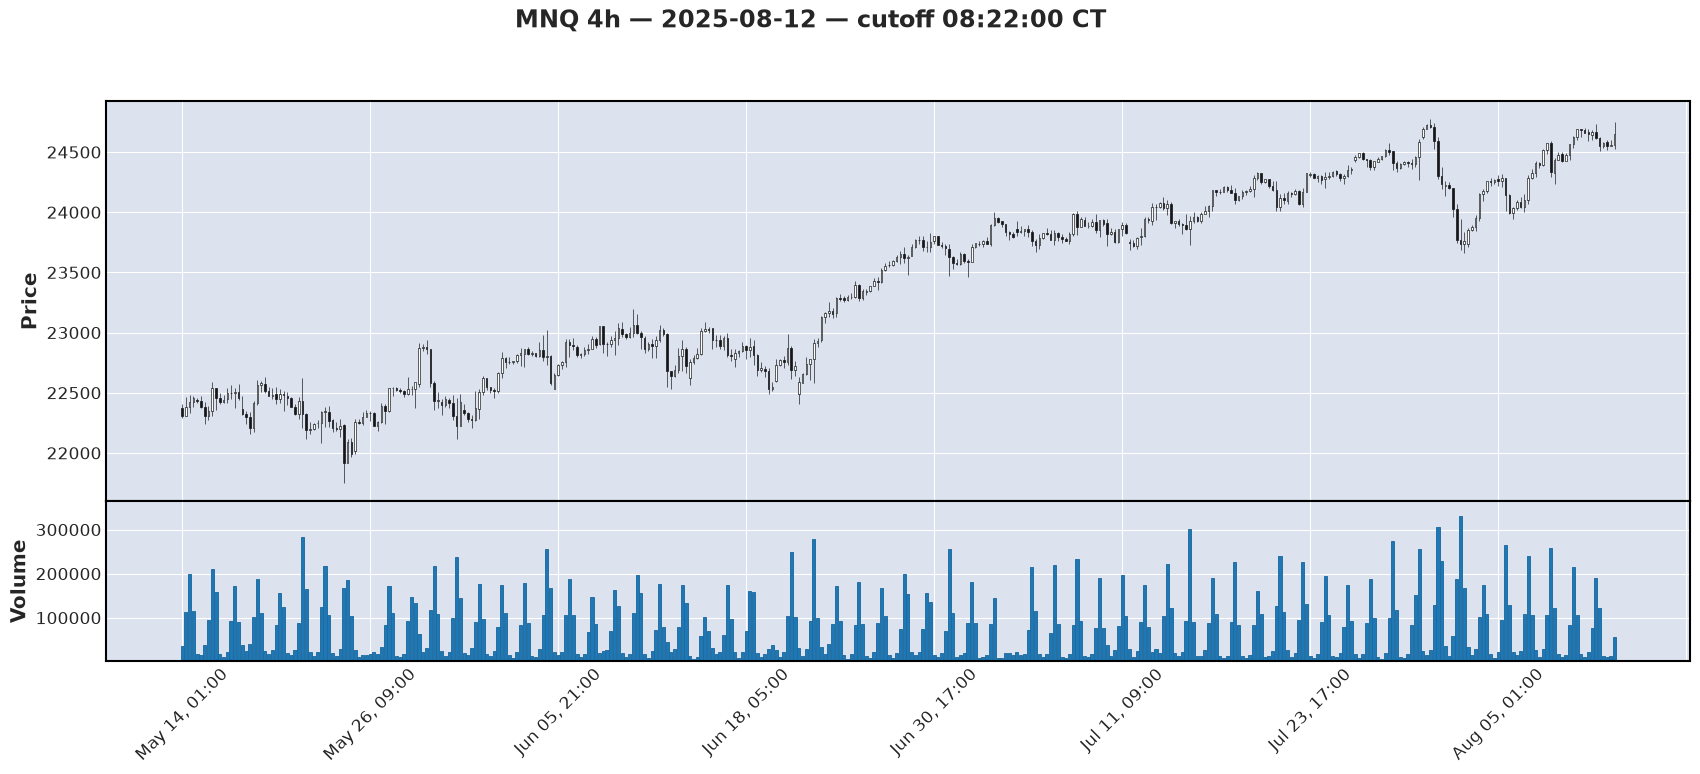

In [113]:
chart_4h = df_4h.loc[target_date - pd.Timedelta(days=90):cutoff]

mpf.plot(
    chart_4h,
    type="candle",
    volume=True,
    figsize=(22, 8),
    title=f"MNQ 4h — {TARGET_DATE} — cutoff {CUTOFF_TIME} CT"
)

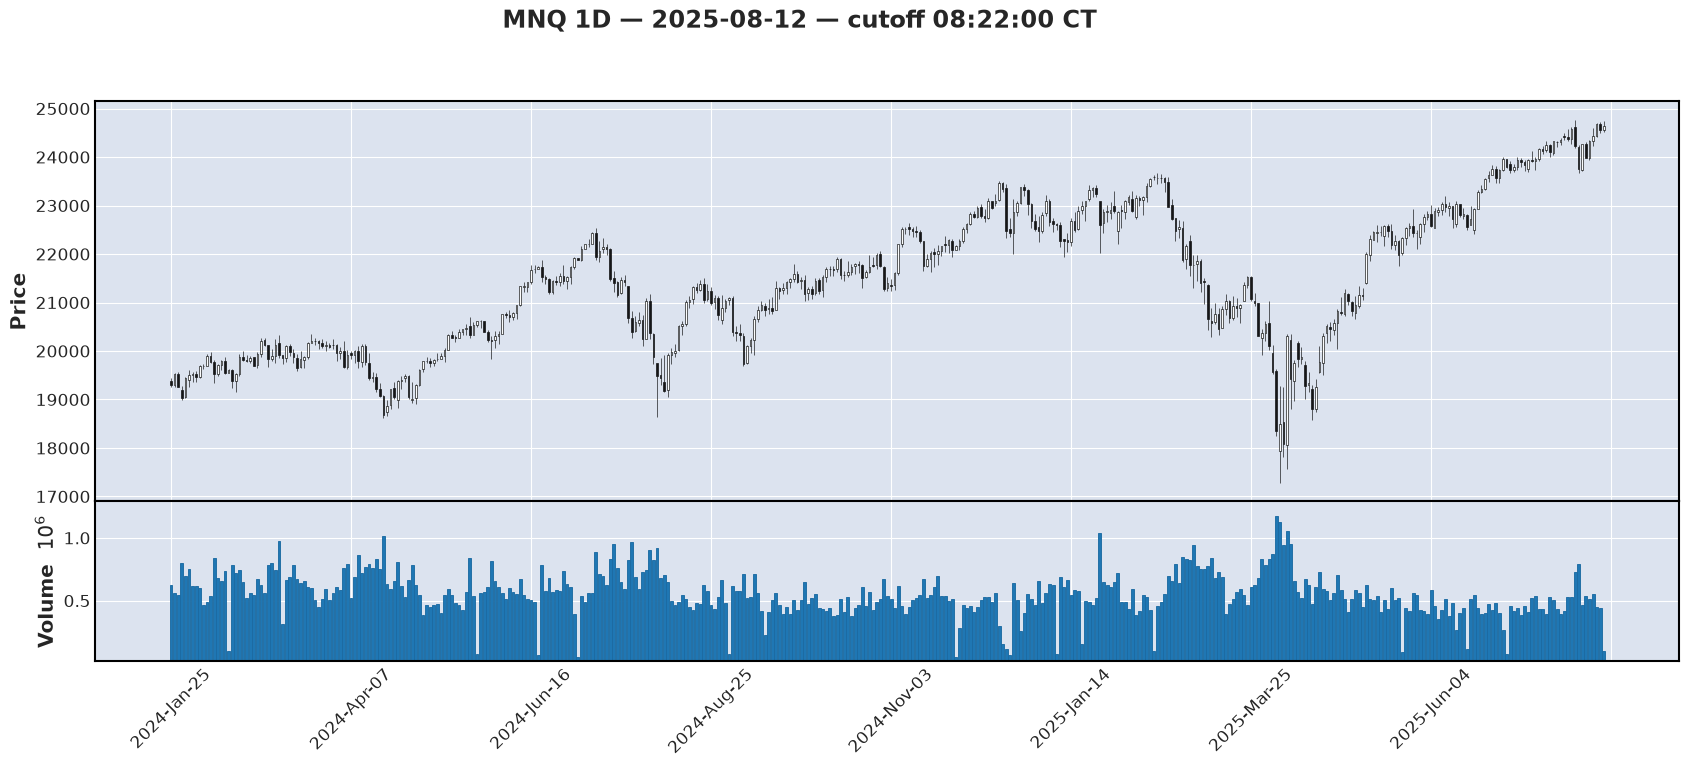

In [111]:
chart_1d = df_1d.loc[start_time:cutoff]

mpf.plot(
    chart_1d,
    type="candle",
    volume=True,
    figsize=(22, 8),
    title=f"MNQ 1D — {TARGET_DATE} — cutoff {CUTOFF_TIME} CT"
)

In [117]:
from pathlib import Path

output_dir = Path("replays") / TARGET_DATE
output_dir.mkdir(parents=True, exist_ok=True)

output_dir

PosixPath('replays/2025-08-12')

In [118]:
mpf.plot(
    chart_1m,
    type="candle",
    volume=True,
    figsize=(22, 8),
    title=f"MNQ 1m — {TARGET_DATE} — cutoff {CUTOFF_TIME} CT",
    warn_too_much_data=1000,
    savefig=output_dir / "1m.png"
)

In [121]:
mpf.plot(
    chart_5m,
    type="candle",
    volume=True,
    figsize=(22, 8),
    title=f"MNQ 5m — {TARGET_DATE} — cutoff {CUTOFF_TIME} CT",
    savefig=output_dir / "5m.png"
)

In [122]:
mpf.plot(
    chart_30m,
    type="candle",
    volume=True,
    figsize=(22, 8),
    title=f"MNQ 30m — {TARGET_DATE} — cutoff {CUTOFF_TIME} CT",
    savefig=output_dir / "30m.png"
)

In [123]:
mpf.plot(
    chart_4h,
    type="candle",
    volume=True,
    figsize=(22, 8),
    title=f"MNQ 4h — {TARGET_DATE} — cutoff {CUTOFF_TIME} CT",
    savefig=output_dir / "4h.png"
)

In [125]:
mpf.plot(
    chart_1d,
    type="candle",
    volume=True,
    figsize=(22, 8),
    title=f"MNQ 1D — {TARGET_DATE} — cutoff {CUTOFF_TIME} CT",
    savefig=output_dir / "1D.png"
)

In [127]:
import json

with open(output_dir / "context.json", "w") as f:
    json.dump(
        context,
        f,
        indent=2,
        default=lambda x: x.item()
    )

In [129]:
df_5m.tail(200).to_csv(output_dir / "nq_data.csv")

In [130]:
sorted(p.name for p in output_dir.iterdir())

['1D.png',
 '1m.png',
 '30m.png',
 '4h.png',
 '5m.png',
 'context.json',
 'nq_data.csv']

In [131]:
import shutil

shutil.make_archive(
    str(output_dir),
    "zip",
    root_dir=output_dir
)

'/home/lhorde/code/LhordeS/trading-app/DailyEdge/notebooks/replays/2025-08-12.zip'